# 📧 Spam Email Classifier

This notebook builds a machine learning model that detects **spam vs. ham (legitimate) emails** based on email content.

**Pipeline:**
1. Load & explore the dataset
2. Clean and preprocess the email text
3. Convert text to numerical features with **TF-IDF**
4. Train two classifiers — **Multinomial Naive Bayes** and **Support Vector Machine (SVM)**
5. Evaluate and compare both models
6. Test the final model on new, unseen email examples
7. Save the trained model for reuse

**Dataset:** `emails.csv` — contains two columns, `text` (the raw email content) and `spam` (1 = spam, 0 = ham).

## 1. Import Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

## 2. Load the Dataset

The dataset has two columns:
- `text`: the raw email content (subject + body)
- `spam`: the label (`1` = spam, `0` = ham/legitimate)

In [2]:
df = pd.read_csv("emails.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [3]:
# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Drop duplicate emails (keeps the model from overfitting on repeated samples)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"\nShape after removing duplicates: {df.shape}")

Missing values:
 text    0
spam    0
dtype: int64

Duplicate rows: 33

Shape after removing duplicates: (5695, 2)


## 3. Exploratory Data Analysis (EDA)

spam
0    4327
1    1368
Name: count, dtype: int64

Spam ratio: 24.02%


/tmp/ipykernel_579/2393968609.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Ham (0)", "Spam (1)"], y=class_counts.values, palette=["#4C72B0", "#C44E52"], ax=ax)


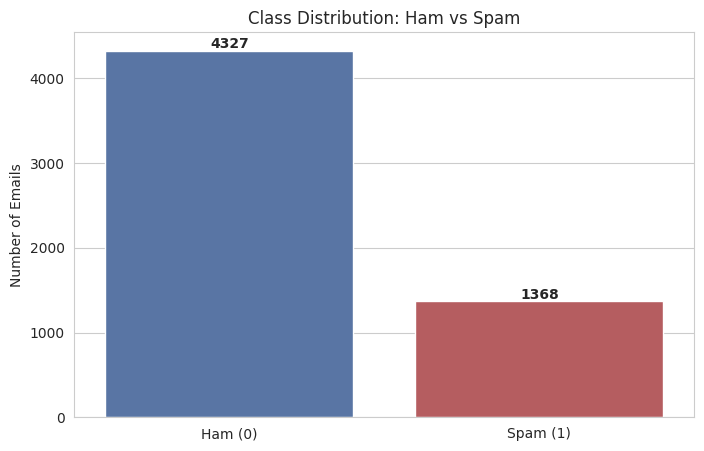

In [4]:
# Class balance
class_counts = df["spam"].value_counts()
print(class_counts)
print(f"\nSpam ratio: {class_counts[1] / len(df):.2%}")

fig, ax = plt.subplots()
sns.barplot(x=["Ham (0)", "Spam (1)"], y=class_counts.values, palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Class Distribution: Ham vs Spam")
ax.set_ylabel("Number of Emails")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.show()

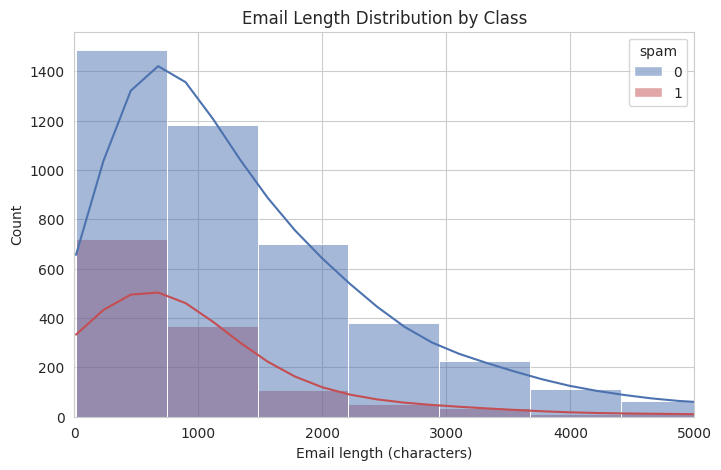

,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
0,4327.0,1634.200139,1965.016383,13.0,577.5,1122.0,2037.50,43952.0
1,1368.0,1317.257310,2271.372893,18.0,401.5,693.5,1250.25,28432.0


In [5]:
# Email length distribution
df["email_length"] = df["text"].apply(len)

fig, ax = plt.subplots()
sns.histplot(data=df, x="email_length", hue="spam", bins=60, kde=True, ax=ax,
             palette={0: "#4C72B0", 1: "#C44E52"})
ax.set_xlim(0, 5000)
ax.set_title("Email Length Distribution by Class")
ax.set_xlabel("Email length (characters)")
plt.show()

df.groupby("spam")["email_length"].describe()

In [6]:
# A peek at a few raw emails
for label, name in [(0, "HAM"), (1, "SPAM")]:
    sample = df[df["spam"] == label]["text"].iloc[0]
    print(f"--- Example {name} email ---")
    print(sample[:300], "...\n")

--- Example HAM email ---
Subject: hello guys ,  i ' m " bugging you " for your completed questionnaire and for a one - page  bio / statement on your thoughts on " business edu and the new economy " . if  my records are incorrect please re - ship your responses to me . i want to  put everything together next week so that i c ...

--- Example SPAM email ---
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that h ...



## 4. Text Preprocessing

We clean the raw email text before feeding it to the model:
- Lowercase everything
- Strip the leading `"Subject:"` tag
- Remove punctuation, numbers, and extra whitespace
- Remove common English stopwords (e.g. "the", "is", "and") and very short tokens

We use scikit-learn's built-in stopword list so the notebook has no extra dependencies (e.g. NLTK corpora downloads).

In [7]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"^subject:", "", text)          # remove leading "subject:" tag
    text = re.sub(r"[^a-z\s]", " ", text)           # keep only letters
    text = re.sub(r"\s+", " ", text).strip()        # collapse whitespace
    words = [w for w in text.split() if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(3)

,text,clean_text
0,Subject: naturally irresistible your corporate...,naturally irresistible corporate identity real...
1,Subject: the stock trading gunslinger fanny i...,stock trading gunslinger fanny merrill muzo co...
2,Subject: unbelievable new homes made easy im ...,unbelievable new homes easy wanting homeowner ...


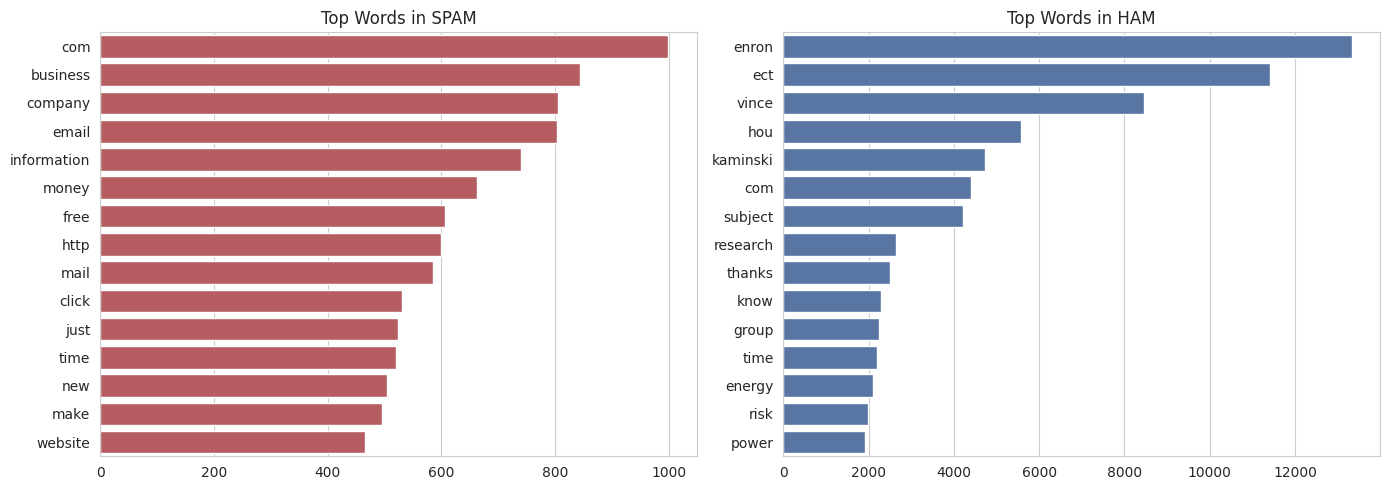

In [8]:
# Most frequent words in spam vs ham (after cleaning) — quick sanity check
from collections import Counter

def top_words(series, n=15):
    counter = Counter(" ".join(series).split())
    return counter.most_common(n)

spam_top = top_words(df[df.spam == 1]["clean_text"])
ham_top = top_words(df[df.spam == 0]["clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in [
    (axes[0], spam_top, "Top Words in SPAM", "#C44E52"),
    (axes[1], ham_top, "Top Words in HAM", "#4C72B0"),
]:
    words, counts = zip(*data)
    sns.barplot(x=list(counts), y=list(words), ax=ax, color=color)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 5. Train/Test Split & Feature Extraction (TF-IDF)

We split the data first, then fit the TF-IDF vectorizer **only on the training set** to avoid data leakage.

In [9]:
X = df["clean_text"]
y = df["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Train spam ratio: {y_train.mean():.2%}  |  Test spam ratio: {y_test.mean():.2%}")

Train size: 4556  |  Test size: 1139
Train spam ratio: 24.01%  |  Test spam ratio: 24.06%


In [10]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_vec.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_vec.shape}")

TF-IDF matrix shape (train): (4556, 5000)
TF-IDF matrix shape (test):  (1139, 5000)


## 6. Train the Models

We train two classic, fast, and effective text-classification algorithms:
- **Multinomial Naive Bayes** — a probabilistic model that works very well for word-count/TF-IDF features
- **Support Vector Machine (Linear SVM)** — finds the optimal hyperplane separating spam from ham in feature space

In [11]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes trained.")

Naive Bayes trained.


In [12]:
svm_model = LinearSVC(random_state=RANDOM_STATE)
svm_model.fit(X_train_vec, y_train)
svm_pred = svm_model.predict(X_test_vec)

print("SVM trained.")

SVM trained.


## 7. Model Evaluation

In [13]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    evaluate("Naive Bayes", y_test, nb_pred),
    evaluate("SVM", y_test, svm_pred),
]).set_index("Model")

results.style.format("{:.4f}").background_gradient(cmap="Greens")

,Accuracy,Precision,Recall,F1-score
Model,,,,
Naive Bayes,0.9842,0.9741,0.9599,0.9669
SVM,0.9912,0.9889,0.9745,0.9816


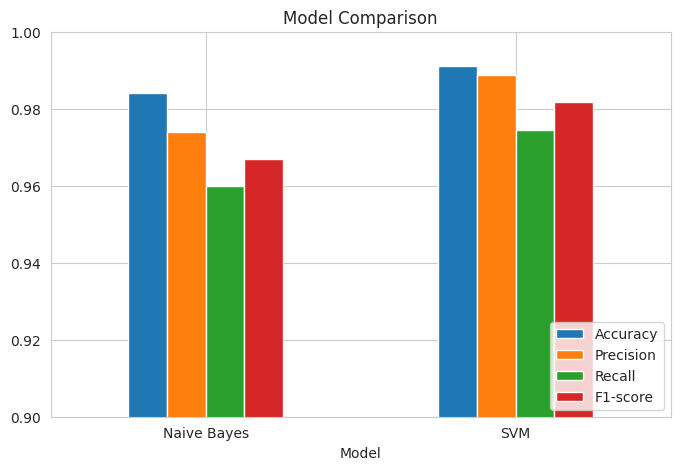

In [14]:
fig, ax = plt.subplots()
results.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Model Comparison")
ax.set_ylim(0.9, 1.0)
ax.legend(loc="lower right")
plt.show()

In [15]:
print("Naive Bayes — Classification Report\n")
print(classification_report(y_test, nb_pred, target_names=["Ham", "Spam"]))
print("\nSVM — Classification Report\n")
print(classification_report(y_test, svm_pred, target_names=["Ham", "Spam"]))

Naive Bayes — Classification Report

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       865
        Spam       0.97      0.96      0.97       274

    accuracy                           0.98      1139
   macro avg       0.98      0.98      0.98      1139
weighted avg       0.98      0.98      0.98      1139


SVM — Classification Report

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       865
        Spam       0.99      0.97      0.98       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139



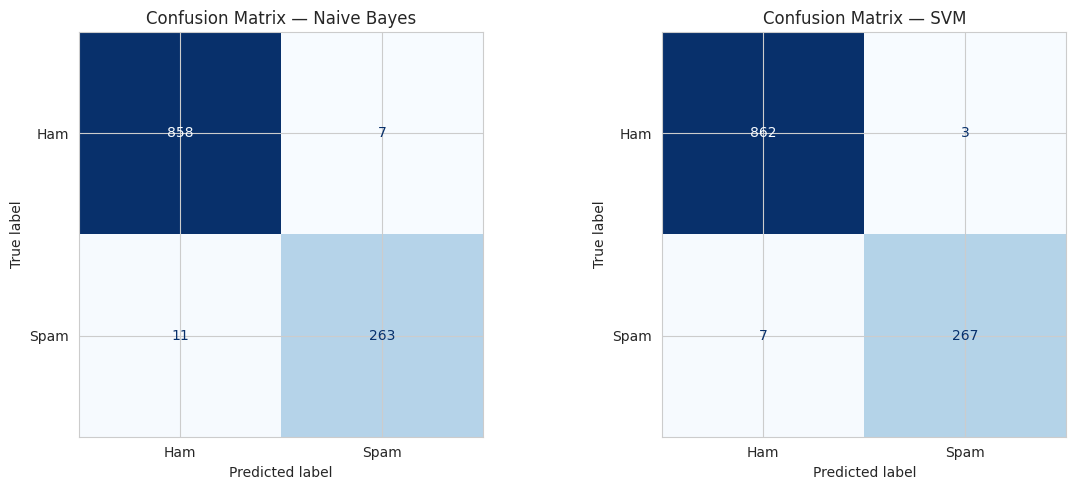

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in [(axes[0], nb_pred, "Naive Bayes"), (axes[1], svm_pred, "SVM")]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {title}")
plt.tight_layout()
plt.show()

In [17]:
# 5-fold cross-validation for a more robust performance estimate
X_all_vec = tfidf.transform(X)  # reuse vectorizer fit on training data

nb_cv = cross_val_score(MultinomialNB(), X_all_vec, y, cv=5, scoring="f1")
svm_cv = cross_val_score(LinearSVC(random_state=RANDOM_STATE), X_all_vec, y, cv=5, scoring="f1")

print(f"Naive Bayes  5-fold CV F1: {nb_cv.mean():.4f} (+/- {nb_cv.std():.4f})")
print(f"SVM          5-fold CV F1: {svm_cv.mean():.4f} (+/- {svm_cv.std():.4f})")

Naive Bayes  5-fold CV F1: 0.9652 (+/- 0.0079)
SVM          5-fold CV F1: 0.9820 (+/- 0.0056)


### Picking the best model

Both models perform very well on this dataset. We select the model with the higher F1-score (a balanced measure of precision and recall) as our final model — this matters in spam filtering because we want to minimize **both** false positives (legit email marked spam) and false negatives (spam reaching the inbox).

In [18]:
best_name = results["F1-score"].idxmax()
best_model = svm_model if best_name == "SVM" else nb_model
print(f"Best model: {best_name} (F1-score = {results.loc[best_name, 'F1-score']:.4f})")

Best model: SVM (F1-score = 0.9816)


## 8. Test the Final Model on New, Unseen Emails

In [19]:
sample_emails = [
    "Subject: URGENT! You have won a $1,000,000 prize! Click here now to claim your money before it expires!",
    "Subject: Meeting rescheduled to 3pm tomorrow, please update your calendar accordingly.",
    "Subject: Free Viagra and weight loss pills, limited time offer, buy now click link!!!",
    "Subject: Hi mom, just checking in, can you call me back when you get a chance?",
    "Subject: Congratulations! You've been pre-approved for a loan, no credit check required, apply today.",
]

cleaned = [clean_text(t) for t in sample_emails]
vectors = tfidf.transform(cleaned)
predictions = best_model.predict(vectors)

for email, pred in zip(sample_emails, predictions):
    label = "🚫 SPAM" if pred == 1 else "✅ HAM"
    print(f"{label:10s} | {email[:70]}...")

🚫 SPAM     | Subject: URGENT! You have won a $1,000,000 prize! Click here now to cl...
✅ HAM      | Subject: Meeting rescheduled to 3pm tomorrow, please update your calen...
🚫 SPAM     | Subject: Free Viagra and weight loss pills, limited time offer, buy no...
🚫 SPAM     | Subject: Hi mom, just checking in, can you call me back when you get a...
🚫 SPAM     | Subject: Congratulations! You've been pre-approved for a loan, no cred...


## 9. Save the Trained Model

We persist the vectorizer and the best-performing classifier to disk with `joblib`, so they can be reloaded later without retraining.

In [20]:
joblib.dump(best_model, "spam_classifier_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Saved: spam_classifier_model.pkl, tfidf_vectorizer.pkl")

Saved: spam_classifier_model.pkl, tfidf_vectorizer.pkl


In [21]:
# Quick reload check
loaded_model = joblib.load("spam_classifier_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

test_email = ["Subject: act now, limited time investment opportunity, guaranteed returns!"]
vec = loaded_vectorizer.transform([clean_text(t) for t in test_email])
print("Prediction:", "SPAM" if loaded_model.predict(vec)[0] == 1 else "HAM")

Prediction: SPAM


## 10. Conclusion

- Both **Naive Bayes** and **SVM** achieve high accuracy (~98–99%) at detecting spam from email text using TF-IDF features.
- The **SVM** model generally edges out Naive Bayes on F1-score in this dataset, making it the chosen final model — though both are strong, lightweight choices for production spam filters.
- The pipeline (text cleaning → TF-IDF → classifier) is simple, fast, and easy to retrain on new data.

**Possible improvements:**
- Try additional models (Logistic Regression, Random Forest, or a fine-tuned transformer like BERT)
- Use n-gram tuning or character-level features to catch obfuscated spam (e.g. "v1agra")
- Incorporate metadata features (sender domain, links count, attachment types)
- Handle class imbalance more explicitly (e.g. SMOTE, class weights) if applied to a more imbalanced dataset